In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from SQUIC_functions import *

# Import data

In [2]:
DATASET = "../datasets/AMLSimData/0_100"

accounts = pd.read_csv(f'{DATASET}/accounts.csv')
transactions = pd.read_csv(f'{DATASET}/transactions.csv')

In [3]:
# Create root
balances = {}

# Take users data from account.csv
for _, row in accounts.iterrows():
    acc_id = row["ACCOUNT_ID"] # User id
    open_date = 0
    initial_balance = round(float(row["INIT_BALANCE"]), 2)

    balances[acc_id] = [{"date": open_date,
                         "balance": initial_balance
                        }]
    
    if acc_id == 0: # Check
        print("first user must be 0 => ",str(acc_id))
        print("user 0 initial deposit must be 184.44 => ", initial_balance)

first user must be 0 =>  0
user 0 initial deposit must be 184.44 =>  184.44


In [4]:
# Apply transactions to users' balances
transactions.sort_values(by="TX_ID")

# Track the last balance for each account
current_balances = {acct_id: balances[acct_id][0]["balance"] for acct_id in balances}

for i, (_, row) in enumerate(transactions.iterrows()):
    orig_acct = row["SENDER_ACCOUNT_ID"]
    bene_acct = row["RECEIVER_ACCOUNT_ID"]
    amount = row["TX_AMOUNT"]
    tx_type = row['TX_TYPE']
    date = row["TIMESTAMP"]

    if orig_acct in balances: # check that sender has a deposit
        last_balance = balances[orig_acct][-1]["balance"] # read balance from balances
        if tx_type in ['TRANSFER', 'WITHDRAWAL']: # all TRANSFER in the csv
            new_balance = last_balance - amount

        balances[orig_acct].append({"date": date, "balance": round(new_balance, 2)})
    
    if bene_acct in balances: # check that receiver has a deposit
        last_balance = balances[bene_acct][-1]["balance"]
        if tx_type in ['TRANSFER', 'DEPOSIT']:
            new_balance = last_balance + amount

        balances[bene_acct].append({"date": date, "balance": round(new_balance, 2)})

In [5]:
result = []

for date in sorted(set(transactions["TIMESTAMP"])):
    daily_balances = {
        "date": date,
        "balances": {
            str(user): {
                "balance": next((entry["balance"] for entry in reversed(b) if entry["date"] <= date), b[0]["balance"])
            } for user, b in balances.items()}
    }
    result.append(daily_balances)

In [6]:
df = pd.DataFrame(result)

# Unpack 'balances' into separate columns for each user
df = df.join(pd.DataFrame(df['balances'].tolist()))

df.drop('balances', axis=1, inplace=True)
df.set_index('date', inplace=True)
df.drop('_id', axis=1, inplace=True, errors='ignore')

for col in df.columns:
    df[col] = df[col].apply(lambda x: x['balance'] if isinstance(x, dict) else x)

In [7]:
df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.80,142.06,125.89,151.13,140.49,178.38,130.33,147.66,158.34,...,411.76,331.00,340.34,426.02,463.36,411.81,437.84,238.28,386.67,297.29
1,184.44,0.00,142.06,125.89,182.79,140.49,194.34,130.33,163.62,31.70,...,411.76,346.06,356.30,426.02,463.36,411.81,452.90,238.28,386.67,297.29
2,253.63,12.38,142.06,138.27,195.17,217.43,194.34,130.33,163.62,92.89,...,485.33,425.57,356.30,426.02,475.74,578.08,452.90,307.47,416.62,12.55
3,322.82,12.38,142.06,138.27,195.17,217.43,264.42,164.84,163.62,92.89,...,517.69,425.57,356.30,461.13,475.74,647.27,452.90,406.85,551.40,147.33
4,322.82,22.28,198.79,138.27,283.92,76.94,264.42,202.88,163.62,92.89,...,758.87,493.80,137.97,478.19,592.32,702.29,165.99,637.58,681.07,272.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1312.03,-3998.92,-1015.09,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2741.40,6605.25,3671.52,1318.73,5914.94,7758.35,9444.49,11741.15,11217.91
196,-1312.03,-3998.92,-1157.14,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2754.61,6605.25,3709.68,1318.73,5932.86,7897.52,9457.70,11788.50,11285.84
197,-1312.03,-3998.92,-1299.19,-929.73,639.73,175.20,-68.40,131.37,-953.47,-571.77,...,5823.71,2800.86,6641.93,3833.55,1418.36,5990.27,8095.31,9607.42,11959.72,11468.65


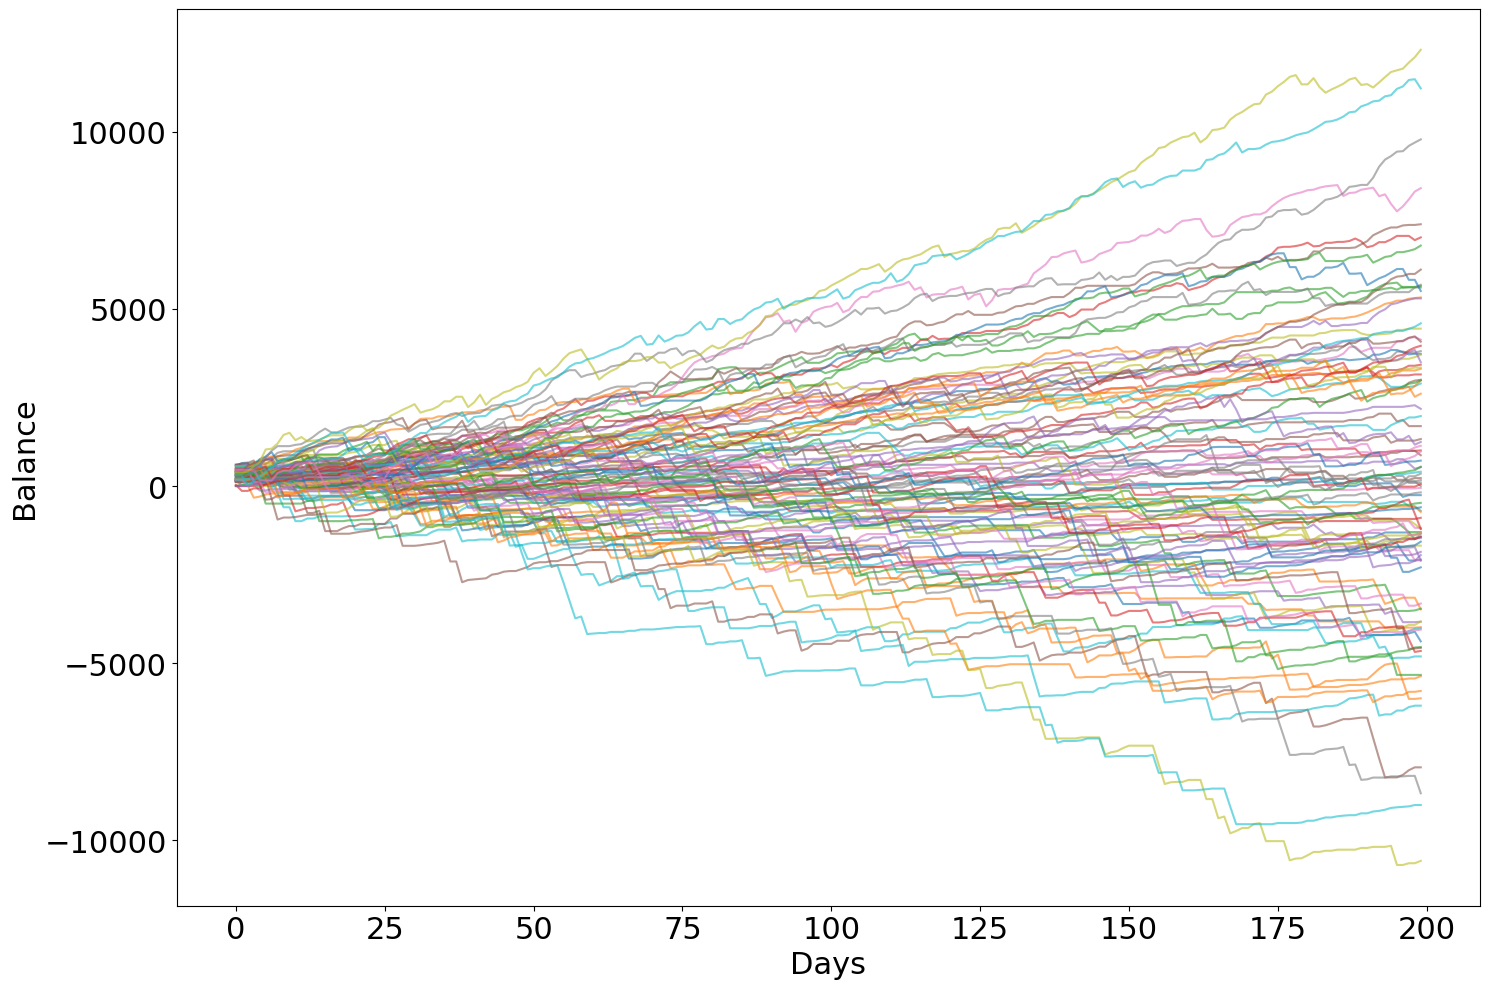

In [8]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in df.columns:
    plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
# plt.title("Balance Evolution of Users Over Time")
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
#plt.xticks(rotation=45)
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Add legend to differentiate users
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

In [9]:
ROWS = len(df.iloc[0])

# Asymmetric transaction matrix

In [10]:
matrix = np.zeros((ROWS, ROWS))

for _, row in transactions.iterrows():
    orig_acct = int(row["SENDER_ACCOUNT_ID"])
    bene_acct = int(row["RECEIVER_ACCOUNT_ID"])
    amount = int(row["TX_AMOUNT"])

    matrix[orig_acct][bene_acct] += amount

matrix_df = pd.DataFrame(matrix)

In [11]:
matrix_df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1932.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1034.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,738.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,738.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,750.0,0.0,0.0,750.0,0.0,750.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,0.0,357.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,357.0,0.0,357.0,357.0,357.0,0.0,0.0,0.0
96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,408.0,0.0,0.0,0.0,408.0,0.0,0.0,408.0,0.0,0.0
97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,230.0,230.0,230.0,230.0,230.0,0.0,230.0
98,0.0,0.0,0.0,0.0,0.0,308.0,0.0,0.0,0.0,0.0,...,308.0,0.0,0.0,308.0,308.0,0.0,0.0,308.0,0.0,308.0


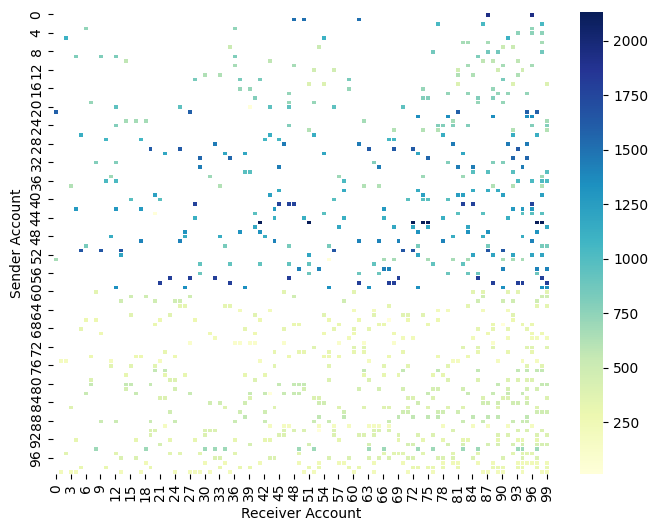

In [12]:
mask = (matrix == 0) # cover all zeros

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, cmap='YlGnBu', fmt=".2f", cbar=True, mask=mask,
            linewidths=0.5, linecolor='white')

plt.xlabel("Receiver Account")
plt.ylabel("Sender Account")
plt.show()

## Squic-Fit

In [13]:
Y = df.T.to_numpy()
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [14]:
l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]

In [15]:
asim_dict = {}

In [16]:
data_nnz = []
data_nnzr = []
data_time = []
data_sim = []

for i, rho in enumerate(l):
    X, computation_time = squic_fit_matrix(Y_new, rho, matrix=matrix)
    asim_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = nnz_fit(asim_dict[rho], ROWS)

    if is_symmetric(asim_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sim.append("Yes")
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sim.append("No")

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        #sparsity_pattern(asim_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        #sparsity_pattern(asim_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        # sparsity_pattern(rho_dict[rho], save=True, path=f"../images/{ROWS}/matrix_sim/{i+1} - matrix {str(rho).replace('.', '_')}.png")
        #sparsity_pattern(asim_dict[rho])

table_asim = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sim
]


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.590000e+01
 Y:         100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=2.96e+01 time=5.12e-04
* iter=1 time=1.17e-03 obj=4.98e+03 |delta(obj)|/obj=9.80e-01 nnz(X,L,W)/p=[2.96e+01 2.21e+01 1.10e+00] lns_iter=3 
* iter=2 time=1.76e-03 obj=4.38e+03 |delta(obj)|/obj=1.37e-01 nnz(X,L,W)/p=[2.96e+01 2.21e+01 5.07e+01] lns_iter=4 
* iter=3 time=7.13e-03 obj=3.88e+03 |de

# Symmetric transaction matrix

In [17]:
smatrix = np.zeros((ROWS, ROWS))

for _, row in transactions.iterrows():
    orig_acct = int(row["SENDER_ACCOUNT_ID"])
    bene_acct = int(row["RECEIVER_ACCOUNT_ID"])
    amount = int(row["TX_AMOUNT"])

    smatrix[orig_acct][bene_acct] += amount
    smatrix[bene_acct][orig_acct] += amount

smatrix_df = pd.DataFrame(smatrix)

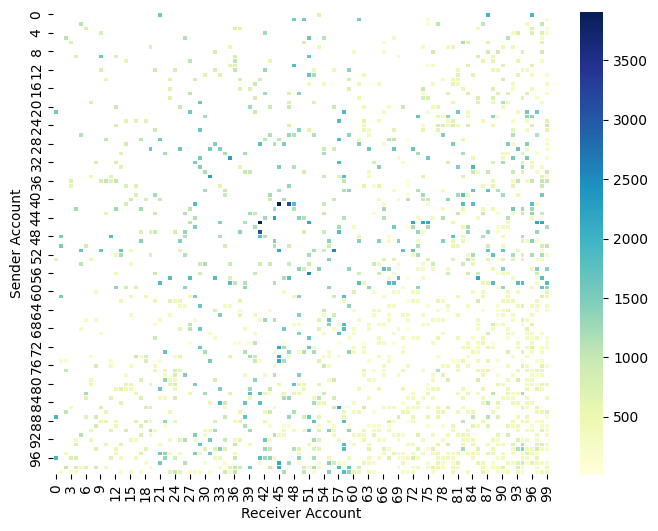

In [18]:
mask = (smatrix == 0) # cover all zeros

plt.figure(figsize=(8, 6))
sns.heatmap(smatrix, cmap='YlGnBu', fmt=".2f", cbar=True, mask=mask,
            linewidths=0.5, linecolor='white')

plt.xlabel("Receiver Account")
plt.ylabel("Sender Account")
plt.show()

## Squic-Fit

In [19]:
Y = df.T.to_numpy()
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [20]:
l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]

In [21]:
sim_dict = {}

In [22]:
data_nnz = []
data_nnzr = []
data_time = []
data_sim = []

for i, rho in enumerate(l):
    X, computation_time = squic_fit_matrix(Y_new, rho, matrix=matrix)
    sim_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = nnz_fit(sim_dict[rho], ROWS)

    if is_symmetric(sim_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sim.append("Yes")
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sim.append("No")

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        #sparsity_pattern(sim_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        #sparsity_pattern(sim_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        # sparsity_pattern(rho_dict[rho], save=True, path=f"../images/{ROWS}/matrix_sim/{i+1} - matrix {str(rho).replace('.', '_')}.png")
        #sparsity_pattern(sim_dict[rho])

table_sim = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sim
]


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.590000e+01
 Y:         100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=2.96e+01 time=2.86e-04
* iter=1 time=1.09e-03 obj=4.98e+03 |delta(obj)|/obj=9.80e-01 nnz(X,L,W)/p=[2.96e+01 2.21e+01 1.10e+00] lns_iter=3 
* iter=2 time=2.00e-03 obj=4.38e+03 |delta(obj)|/obj=1.37e-01 nnz(X,L,W)/p=[2.96e+01 2.21e+01 5.07e+01] lns_iter=4 
* iter=3 time=6.73e-03 obj=3.88e+03 |de

# Table

In [23]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [24]:
print(table(table_asim, "Asymmetric Trans Matrix", l))

print(table(table_sim, "Symmetric Trans Matrix", l))

╒═══════════════════════════╤═══════╤═══════╤═══════╤═══════╤════════╤════════╤════════╤═════════╤═════════╤═════════╤══════════╕
│  Asymmetric Trans Matrix  │  0.9  │  0.5  │  0.2  │  0.1  │  0.09  │  0.05  │  0.01  │  0.009  │  0.005  │  0.001  │  0.0001  │
╞═══════════════════════════╪═══════╪═══════╪═══════╪═══════╪════════╪════════╪════════╪═════════╪═════════╪═════════╪══════════╡
│            NNZ            │ 1590  │ 2090  │ 1502  │ 4114  │  1542  │  1772  │  4124  │  4118   │  4066   │  4220   │   4078   │
├───────────────────────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼─────────┼─────────┼─────────┼──────────┤
│          NNZ/Row          │ 15.9  │ 20.9  │ 15.02 │ 41.14 │ 15.42  │ 17.72  │ 41.24  │  41.18  │  40.66  │  42.2   │  40.78   │
├───────────────────────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼─────────┼─────────┼─────────┼──────────┤
│         Time (s)          │ 7.26  │ 0.25  │ 2.46  │ 0.15  │  8.46  │ 10.96  │  21.3  │  